# V3 Feature Engineering — V2.5 + Cross-Border Grid Transmission

Extends V2.5 (51 columns) with Finland cross-border electricity flows from Fingrid.

**New features added:**
- `fi_ee` — Finland↔Estonia net flow (MW), Estlink 1+2
- `fi_no` — Finland↔Norway net flow (MW)
- `fi_se_north` — Finland↔Northern Sweden (SE1), 15-min measured
- `fi_se_central` — Finland↔Central Sweden (SE3), 15-min measured
- `fi_se_total` — Combined Sweden flow (fi_se_north + fi_se_central)
- `fi_total_net` — Total cross-border net flow (all corridors)
- `fi_se_abs` — |fi_se_total|, proxy for SE corridor congestion
- Lag features: fi_total_net, fi_se_total, fi_ee at lag_96 (24h) and lag_672 (7d)

Sign convention: **positive = Finland exports**, negative = Finland imports.

Output: `V3_15min_features.csv`

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

## 1. Load V2.5 Features

In [2]:
df = pd.read_csv('V2.5_15min_features.csv')
df['datetime'] = pd.to_datetime(df['datetime'], utc=True).dt.tz_convert('Europe/Helsinki')
df = df.sort_values('datetime').reset_index(drop=True)

print('V2.5 shape:', df.shape)
print('Date range:', df['datetime'].min(), '→', df['datetime'].max())
print('Columns:', df.columns.tolist())

V2.5 shape: (105216, 51)
Date range: 2023-01-01 00:00:00+02:00 → 2025-12-31 23:45:00+02:00
Columns: ['datetime', 'price', 'temp', 'wind_speed', 'wind_direction_deg', 'wind_dir_sin', 'wind_dir_cos', 'hour', 'minute', 'day_of_week', 'day_of_month', 'month', 'week_of_year', 'quarter', 'year', 'time_of_day', 'season', 'is_weekend', 'is_peak_hour', 'is_night_hour', 'hour_sin', 'hour_cos', 'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'month_cos', 'week_of_year_sin', 'week_of_year_cos', 'is_holiday', 'is_non_working', 'price_lag_1', 'price_lag_2', 'price_lag_4', 'price_lag_8', 'price_lag_16', 'price_lag_32', 'price_lag_96', 'price_lag_672', 'price_rolling_mean_1h', 'price_rolling_std_1h', 'price_rolling_mean_6h', 'price_rolling_mean_24h', 'price_rolling_std_24h', 'price_rolling_min_24h', 'price_rolling_max_24h', 'price_rolling_mean_7d', 'temp_rolling_mean_1h', 'HDD', 'wind_power_proxy', 'temp_lag_4', 'temp_lag_96']


## 2. Load Grid Transmission Data

In [3]:
grid_path = Path('../originalData/GridTransmission/grid_transmission_15min.csv')
grid = pd.read_csv(grid_path)
grid['datetime'] = pd.to_datetime(grid['datetime'], utc=True).dt.tz_convert('Europe/Helsinki')
grid = grid.sort_values('datetime').reset_index(drop=True)

print('Grid shape:', grid.shape)
print('Date range:', grid['datetime'].min(), '→', grid['datetime'].max())
print('Grid columns:', grid.columns.tolist())
print('\nNaN counts:')
print(grid.isnull().sum())
grid.head()

Grid shape: (105216, 8)
Date range: 2023-01-01 00:00:00+02:00 → 2025-12-31 23:45:00+02:00
Grid columns: ['datetime', 'fi_ee', 'fi_no', 'fi_se_north', 'fi_se_central', 'fi_se_total', 'fi_total_net', 'fi_se_abs']

NaN counts:
datetime         0
fi_ee            8
fi_no            8
fi_se_north      8
fi_se_central    8
fi_se_total      8
fi_total_net     0
fi_se_abs        8
dtype: int64


,datetime,fi_ee,fi_no,fi_se_north,fi_se_central,fi_se_total,fi_total_net,fi_se_abs
0,2023-01-01 00:00:00+02:00,NaN,NaN,NaN,NaN,NaN,0.0,NaN
1,2023-01-01 00:15:00+02:00,NaN,NaN,NaN,NaN,NaN,0.0,NaN
2,2023-01-01 00:30:00+02:00,NaN,NaN,NaN,NaN,NaN,0.0,NaN
3,2023-01-01 00:45:00+02:00,NaN,NaN,NaN,NaN,NaN,0.0,NaN
4,2023-01-01 01:00:00+02:00,NaN,NaN,NaN,NaN,NaN,0.0,NaN


## 3. Merge on Datetime

Left-join V2.5 onto the grid data.
The 8 NaN rows at the start of the grid data (2023-01-01 00:00–01:45 EET, before UTC midnight)
are back-filled with the first valid value — a small one-off gap with negligible impact on training.

In [4]:
grid_cols = ['datetime', 'fi_ee', 'fi_no', 'fi_se_north', 'fi_se_central',
             'fi_se_total', 'fi_total_net', 'fi_se_abs']

df = df.merge(grid[grid_cols], on='datetime', how='left')

# Back-fill the 8 NaN rows at the very start (before UTC midnight on Jan 1 2023)
grid_flow_cols = ['fi_ee', 'fi_no', 'fi_se_north', 'fi_se_central',
                  'fi_se_total', 'fi_total_net', 'fi_se_abs']
df[grid_flow_cols] = df[grid_flow_cols].bfill()

print('Merged shape:', df.shape)
print('\nGrid NaN counts after bfill:')
print(df[grid_flow_cols].isnull().sum())
df[['datetime'] + grid_flow_cols].head(12)

Merged shape: (105216, 58)

Grid NaN counts after bfill:
fi_ee            0
fi_no            0
fi_se_north      0
fi_se_central    0
fi_se_total      0
fi_total_net     0
fi_se_abs        0
dtype: int64


,datetime,fi_ee,fi_no,fi_se_north,fi_se_central,fi_se_total,fi_total_net,fi_se_abs
0,2023-01-01 00:00:00+02:00,1005.315000,-19.777990,598.42600,173.699990,772.125990,0.000000,772.125990
1,2023-01-01 00:15:00+02:00,1005.315000,-19.777990,598.42600,173.699990,772.125990,0.000000,772.125990
2,2023-01-01 00:30:00+02:00,1005.315000,-19.777990,598.42600,173.699990,772.125990,0.000000,772.125990
3,2023-01-01 00:45:00+02:00,1005.315000,-19.777990,598.42600,173.699990,772.125990,0.000000,772.125990
4,2023-01-01 01:00:00+02:00,1005.315000,-19.777990,598.42600,173.699990,772.125990,0.000000,772.125990
5,2023-01-01 01:15:00+02:00,1005.315000,-19.777990,598.42600,173.699990,772.125990,0.000000,772.125990
6,2023-01-01 01:30:00+02:00,1005.315000,-19.777990,598.42600,173.699990,772.125990,0.000000,772.125990
7,2023-01-01 01:45:00+02:00,1005.315000,-19.777990,598.42600,173.699990,772.125990,0.000000,772.125990
8,2023-01-01 02:00:00+02:00,1005.315000,-19.777990,598.42600,173.699990,772.125990,1757.663000,772.125990
9,2023-01-01 02:15:00+02:00,1007.124997,-18.012242,663.59075,176.444993,840.035743,1829.148498,840.035743


## 4. Grid Lag Features

In production the model won't have the current-period grid flow for future steps.
Lag features at 24h and 7d are always available at inference time (from yesterday/last week).
These are the most important grid features for the model to learn seasonal/weekly congestion patterns.

In [5]:
# lag_96 = 24 hours ago (96 × 15-min steps)
# lag_672 = 7 days ago (672 × 15-min steps)
for col in ['fi_total_net', 'fi_se_total', 'fi_ee']:
    df[f'{col}_lag_96']  = df[col].shift(96)
    df[f'{col}_lag_672'] = df[col].shift(672)

lag_cols = [c for c in df.columns if 'fi_' in c and 'lag' in c]
print('Grid lag columns added:', lag_cols)
print('\nNaN counts for grid lags (expected: 96 and 672 at start):')
print(df[lag_cols].isnull().sum())

Grid lag columns added: ['fi_total_net_lag_96', 'fi_total_net_lag_672', 'fi_se_total_lag_96', 'fi_se_total_lag_672', 'fi_ee_lag_96', 'fi_ee_lag_672']

NaN counts for grid lags (expected: 96 and 672 at start):
fi_total_net_lag_96      96
fi_total_net_lag_672    672
fi_se_total_lag_96       96
fi_se_total_lag_672     672
fi_ee_lag_96             96
fi_ee_lag_672           672
dtype: int64


## 5. Sanity Check

In [6]:
print(f'Total columns: {len(df.columns)}')
print(f'Total rows:    {len(df)}')
print(f'\nNew V3 columns vs V2.5:')
v25_cols = set(pd.read_csv('V2.5_15min_features.csv', nrows=0).columns)
new_cols = [c for c in df.columns if c not in v25_cols]
print(new_cols)
print(f'\nTotal new features: {len(new_cols)}')
print(f'\nAll columns:')
print(df.columns.tolist())

Total columns: 64
Total rows:    105216

New V3 columns vs V2.5:
['fi_ee', 'fi_no', 'fi_se_north', 'fi_se_central', 'fi_se_total', 'fi_total_net', 'fi_se_abs', 'fi_total_net_lag_96', 'fi_total_net_lag_672', 'fi_se_total_lag_96', 'fi_se_total_lag_672', 'fi_ee_lag_96', 'fi_ee_lag_672']

Total new features: 13

All columns:
['datetime', 'price', 'temp', 'wind_speed', 'wind_direction_deg', 'wind_dir_sin', 'wind_dir_cos', 'hour', 'minute', 'day_of_week', 'day_of_month', 'month', 'week_of_year', 'quarter', 'year', 'time_of_day', 'season', 'is_weekend', 'is_peak_hour', 'is_night_hour', 'hour_sin', 'hour_cos', 'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'month_cos', 'week_of_year_sin', 'week_of_year_cos', 'is_holiday', 'is_non_working', 'price_lag_1', 'price_lag_2', 'price_lag_4', 'price_lag_8', 'price_lag_16', 'price_lag_32', 'price_lag_96', 'price_lag_672', 'price_rolling_mean_1h', 'price_rolling_std_1h', 'price_rolling_mean_6h', 'price_rolling_mean_24h', 'price_rolling_std_24h', 'pri

In [7]:
print('NaN counts (only columns with NaN):')
nan_counts = df.isnull().sum()
print(nan_counts[nan_counts > 0])

print('\nGrid flow statistics:')
df[grid_flow_cols].describe()

NaN counts (only columns with NaN):
temp                       48
wind_speed                160
wind_direction_deg        160
wind_dir_sin              160
wind_dir_cos              160
price_lag_1                 1
price_lag_2                 2
price_lag_4                 4
price_lag_8                 8
price_lag_16               16
price_lag_32               32
price_lag_96               96
price_lag_672             672
price_rolling_mean_1h       4
price_rolling_std_1h        4
price_rolling_mean_6h      24
price_rolling_mean_24h     96
price_rolling_std_24h      96
price_rolling_min_24h      96
price_rolling_max_24h      96
price_rolling_mean_7d     672
temp_rolling_mean_1h       78
HDD                        48
wind_power_proxy          160
temp_lag_4                 52
temp_lag_96               144
fi_total_net_lag_96        96
fi_total_net_lag_672      672
fi_se_total_lag_96         96
fi_se_total_lag_672       672
fi_ee_lag_96               96
fi_ee_lag_672             672
dtyp

,fi_ee,fi_no,fi_se_north,fi_se_central,fi_se_total,fi_total_net,fi_se_abs
count,105216.000000,105216.000000,105216.000000,105216.000000,105216.000000,105216.000000,105216.000000
mean,523.859881,-26.277320,-571.664362,-330.645431,-902.309793,-404.860874,1123.120157
std,368.322360,34.526299,628.044207,612.129057,993.730610,1095.245692,735.024046
min,-915.380000,-123.504000,-2245.230000,-1231.000000,-3247.080000,-3251.130000,0.030000
25%,362.187500,-50.480000,-1066.120000,-896.592500,-1699.211249,-1207.350250,493.748245
50%,366.700000,-23.675000,-711.784998,-250.321500,-954.210010,-441.807629,1035.885000
75%,937.847500,-0.190000,-89.997500,0.500000,-185.670000,340.989275,1711.047523
max,1038.230000,101.640000,1835.270000,1202.800000,2428.660000,3556.620000,3247.080000


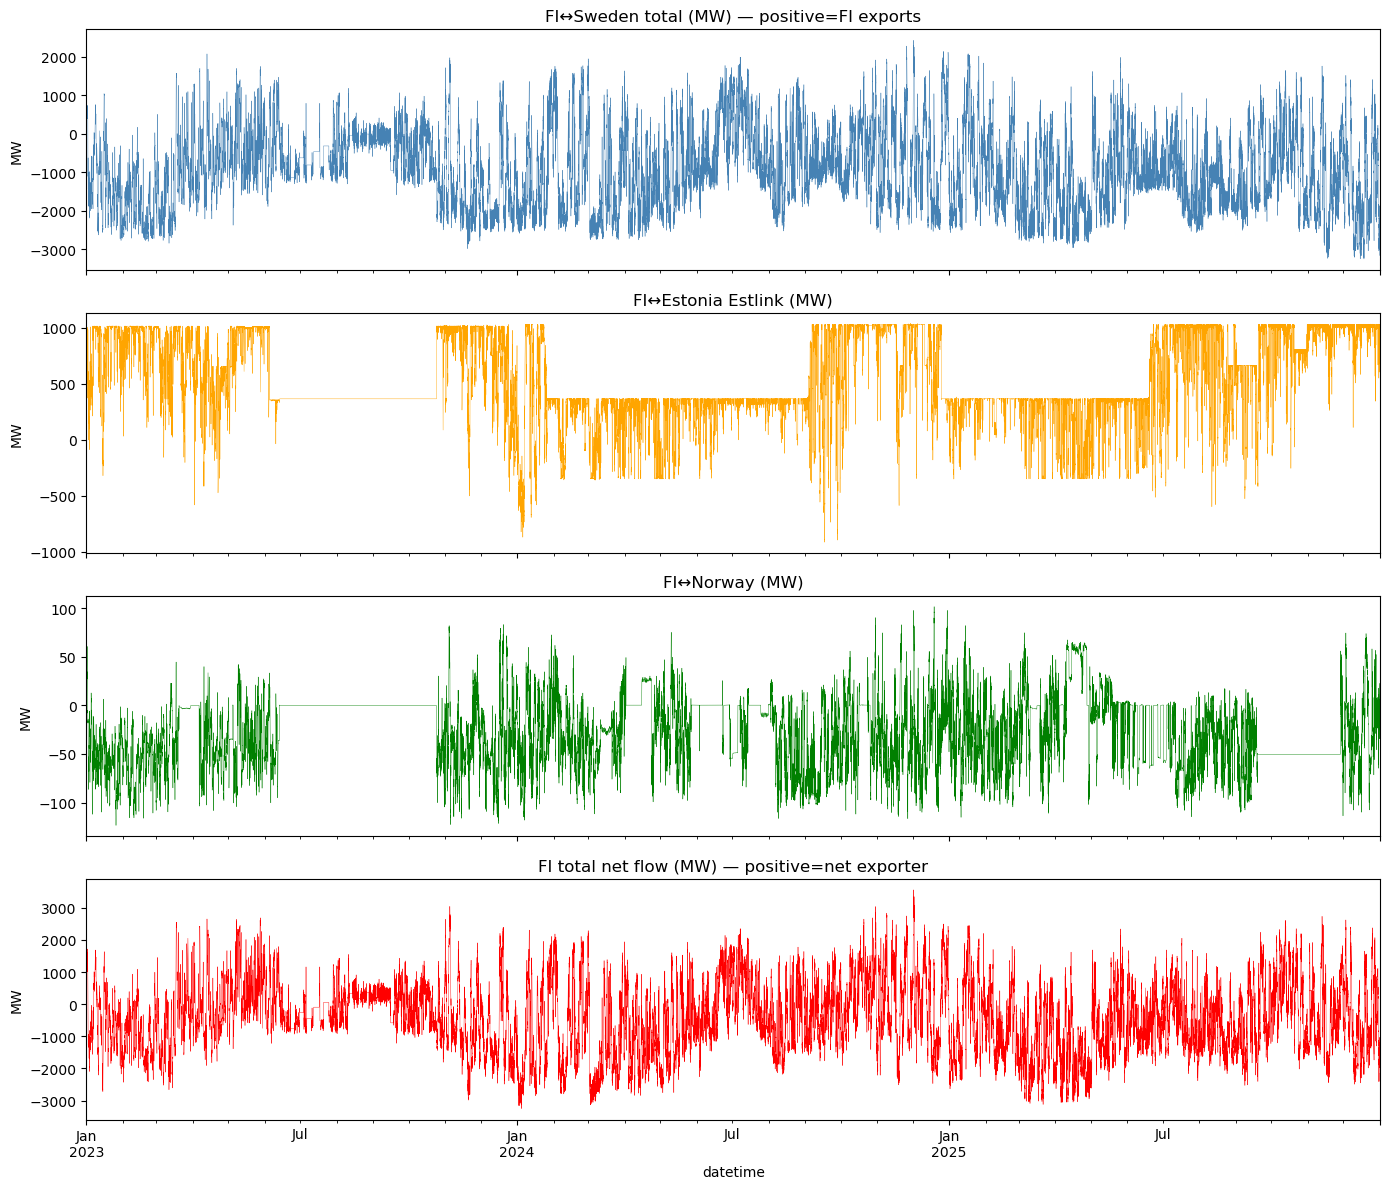

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

df.set_index('datetime')['fi_se_total'].plot(ax=axes[0], linewidth=0.3, color='steelblue')
axes[0].set_title('FI↔Sweden total (MW) — positive=FI exports')
axes[0].set_ylabel('MW')

df.set_index('datetime')['fi_ee'].plot(ax=axes[1], linewidth=0.3, color='orange')
axes[1].set_title('FI↔Estonia Estlink (MW)')
axes[1].set_ylabel('MW')

df.set_index('datetime')['fi_no'].plot(ax=axes[2], linewidth=0.3, color='green')
axes[2].set_title('FI↔Norway (MW)')
axes[2].set_ylabel('MW')

df.set_index('datetime')['fi_total_net'].plot(ax=axes[3], linewidth=0.3, color='red')
axes[3].set_title('FI total net flow (MW) — positive=net exporter')
axes[3].set_ylabel('MW')

plt.tight_layout()
plt.show()

## 6. Save

In [9]:
out_path = 'V3_15min_features.csv'
df.to_csv(out_path, index=False)

print(f'Saved → {out_path}')
print(f'Rows  : {len(df)}')
print(f'Cols  : {len(df.columns)}  (was 51 in V2.5, +{len(df.columns)-51} new grid features)')
print(f'Range : {df["datetime"].min()} → {df["datetime"].max()}')

Saved → V3_15min_features.csv
Rows  : 105216
Cols  : 64  (was 51 in V2.5, +13 new grid features)
Range : 2023-01-01 00:00:00+02:00 → 2025-12-31 23:45:00+02:00
